# IPD — Training Pipeline (Stage 1 + Stage 2)

Colab GPU notebook for fine-tuning **ViT-B/16** (`google/vit-base-patch16-224`) for gender classification.

**Why ViT, not CLIP?** CLIP is a vision-language model — its value is the joint image-text embedding space. Reducing it to a binary classification head wastes that. ViT is a pure vision backbone, pretrained on ImageNet-21k, better suited for fine-tuning on a visual attribute task.

**Stage 1**: Fine-tune on PETA + RAP + SCface → `checkpoints/stage1/`  
**Stage 2**: Continue fine-tuning on YOUR labeled data, lower LR → `checkpoints/stage2/`

Gender only — no age classification.


## 0. Setup

In [2]:
# Install dependencies (Colab)
!pip install -q opencv-python-headless opencv-contrib-python-headless \
                ultralytics transformers h5py scipy pyyaml matplotlib

import torch
print('torch', torch.__version__, 'cuda:', torch.cuda.is_available())
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', DEVICE)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.5/69.5 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 56.1 MB/s eta 0:00:00
torch 2.11.0+cu128 cuda: True
Using device: cuda


In [3]:
# Mount Google Drive (for saving checkpoints across sessions)
!fusermount -u /content/drive 2>/dev/null
!rm -rf /content/drive

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

DRIVE_CKPT_DIR = '/content/drive/MyDrive/IPD_checkpoints'
import os
os.makedirs(DRIVE_CKPT_DIR, exist_ok=True)
print('Checkpoints will be saved to:', DRIVE_CKPT_DIR)

Mounted at /content/drive
Checkpoints will be saved to: /content/drive/MyDrive/IPD_checkpoints


## 1. Config

All knobs in one cell. Edit and re-run from here if you want to change anything.

In [4]:
import torch, os, json, time, math, csv, shutil, sys
from pathlib import Path
from dataclasses import dataclass, field
from typing import Any, Dict, List, Optional, Tuple, Callable
from collections import defaultdict
import numpy as np
from PIL import Image
import cv2
import yaml

CONFIG = {
    'backbone': 'google/vit-base-patch16-224',   # pure ViT, ImageNet-21k pretrained
    'image_size': 224,
    'seed': 42,

    # Dataset roots (set after organizing — see Section 3)
    'peta_csv':    '/content/data/PETA/labels.csv',
    'peta_imgs':   '/content/data/PETA/images',
    'rap_csv':     '/content/data/RAP/labels.csv',
    'rap_imgs':    '/content/data/RAP/images',
    'scface_csv':  '/content/data/SCface/labels.csv',
    'scface_imgs': '/content/data/SCface/images',

    'val_ratio': 0.1,

    # Stage 1 training
    'stage1': {
        'output_dir': '/content/checkpoints/stage1',
        'phase_a_epochs': 3,
        'phase_a_head_lr': 1e-3,
        'phase_b_epochs': 10,
        'phase_b_head_lr': 1e-5,
        'phase_b_backbone_lr': 1e-5,
        'batch_size': 64,
        'eval_batch_size': 128,
        'num_workers': 4,
        'weight_decay': 0.01,
        'warmup_ratio': 0.1,
        'grad_clip': 1.0,
        'fp16': True,
        'log_every': 50,
    },

    # Stage 2 training (your data)
    'stage2': {
        'init_from': '/content/checkpoints/stage1/best',
        'output_dir': '/content/checkpoints/stage2',
        'user_data_root': '/content/data/user',   # folder-per-class: male/, female/
        'val_ratio': 0.15,
        'phase_a_epochs': 2,
        'phase_a_head_lr': 1e-4,           # 1/10 of stage 1
        'phase_b_epochs': 5,
        'phase_b_head_lr': 1e-6,           # 1/10 of stage 1
        'phase_b_backbone_lr': 1e-6,
        'batch_size': 32,
        'eval_batch_size': 64,
        'num_workers': 4,
        'weight_decay': 0.01,
        'warmup_ratio': 0.1,
        'grad_clip': 1.0,
        'fp16': True,
        'log_every': 20,
    },
}

torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
print('Config loaded. Backbone:', CONFIG['backbone'], '(pure ViT, no language component)')


Config loaded. Backbone: google/vit-base-patch16-224 (pure ViT, no language component)


## 2. Helper functions

Self-contained: transforms, datasets, model, trainer. No `src/` imports needed.

In [5]:
# === Transforms (ViT, NOT CLIP) ===
from transformers import ViTImageProcessor
_VIT_PROC = ViTImageProcessor.from_pretrained(CONFIG['backbone'])

def _to_tensor(pil_img):
    out = _VIT_PROC(images=pil_img, return_tensors='pt')
    return out['pixel_values'][0]

def train_transform(pil_img):
    if torch.rand(1).item() < 0.5:
        pil_img = pil_img.transpose(Image.FLIP_LEFT_RIGHT)
    from PIL import ImageEnhance
    pil_img = ImageEnhance.Brightness(pil_img).enhance(0.9 + 0.1*torch.rand(1).item())
    pil_img = ImageEnhance.Contrast(pil_img).enhance(0.9 + 0.1*torch.rand(1).item())
    pil_img = ImageEnhance.Color(pil_img).enhance(0.9 + 0.1*torch.rand(1).item())
    return _to_tensor(pil_img)

def val_transform(pil_img):
    return _to_tensor(pil_img)

print('Transforms ready (ViTImageProcessor).')


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Transforms ready (ViTImageProcessor).


In [6]:
# === Datasets ===
from torch.utils.data import Dataset, DataLoader, Subset

GENDER_TO_IDX = {'female': 0, 'male': 1}
IDX_TO_GENDER = {0: 'female', 1: 'male'}

class CSVDataset(Dataset):
    def __init__(self, csv_path, image_root, transform=None):
        self.image_root = Path(image_root)
        self.transform = transform
        self.rows = []
        with open(csv_path) as fh:
            for r in csv.DictReader(fh):
                g = r['gender'].strip().lower()
                if g not in GENDER_TO_IDX: continue
                p = Path(r['image'])
                if not p.is_absolute(): p = self.image_root / p
                if not p.exists(): continue
                self.rows.append((p, GENDER_TO_IDX[g]))
        if not self.rows: raise RuntimeError(f'No valid rows in {csv_path}')
    def __len__(self): return len(self.rows)
    def __getitem__(self, idx):
        p, lab = self.rows[idx]
        img = Image.open(p).convert('RGB')
        if self.transform is not None: img = self.transform(img)
        return img, lab

class FolderPerClassDataset(Dataset):
    def __init__(self, root, transform=None, exts=('.jpg', '.jpeg', '.png')):
        self.root = Path(root)
        self.transform = transform
        self.rows = []
        for name, idx in GENDER_TO_IDX.items():
            d = self.root / name
            if not d.exists(): continue
            for ext in exts:
                for img in d.glob(f'*{ext}'): self.rows.append((img, idx))
                for img in d.glob(f'*{ext.upper()}'): self.rows.append((img, idx))
        if not self.rows: raise RuntimeError(f'No images in {self.root}/{{male,female}}/')
    def __len__(self): return len(self.rows)
    def __getitem__(self, idx):
        p, lab = self.rows[idx]
        img = Image.open(p).convert('RGB')
        if self.transform is not None: img = self.transform(img)
        return img, lab

class ConcatDataset(Dataset):
    def __init__(self, datasets):
        self.datasets = datasets
        self.cum = [0]
        for d in datasets: self.cum.append(self.cum[-1] + len(d))
    def __len__(self): return self.cum[-1]
    def __getitem__(self, idx):
        for i, c in enumerate(self.cum[1:]):
            if idx < c: return self.datasets[i][idx - self.cum[i]]
        raise IndexError(idx)

def stratified_split(rows, val_ratio=0.1, seed=42):
    g = torch.Generator().manual_seed(seed)
    by_class = defaultdict(list)
    for i, (_, lab) in enumerate(rows): by_class[lab].append(i)
    train_idx, val_idx = [], []
    for lab, idxs in by_class.items():
        perm = torch.randperm(len(idxs), generator=g).tolist()
        n_val = int(len(idxs) * val_ratio)
        for j, p in enumerate(perm):
            (val_idx if j < n_val else train_idx).append(idxs[p])
    return train_idx, val_idx

print('Datasets ready.')


Datasets ready.


In [7]:
# === Model: pure ViT backbone + binary gender head ===
import torch.nn as nn
from transformers import ViTModel

class GenderClassifier(nn.Module):
    def __init__(self, vit_model_name='google/vit-base-patch16-224', num_labels=2):
        super().__init__()
        self.vit = ViTModel.from_pretrained(vit_model_name)
        hidden_dim = self.vit.config.hidden_size  # 768 for ViT-base
        self.head = nn.Linear(hidden_dim, num_labels)
        self.num_labels = num_labels
        self.id2label = {0: 'female', 1: 'male'}
        self.label2id = {'female': 0, 'male': 1}
        self.vit_model_name = vit_model_name

    def forward(self, pixel_values):
        out = self.vit(pixel_values=pixel_values)
        pooled = out.pooler_output   # [B, 768]
        return self.head(pooled)     # [B, 2]

    def embed(self, pixel_values):
        '''Penultimate features for ReID (cosine similarity). [B, 768] L2-normalized.'''
        out = self.vit(pixel_values=pixel_values)
        emb = out.pooler_output
        return emb / emb.norm(dim=-1, keepdim=True)

    def freeze_backbone(self):
        for p in self.vit.parameters(): p.requires_grad = False
        for p in self.head.parameters(): p.requires_grad = True

    def unfreeze_backbone(self):
        for p in self.parameters(): p.requires_grad = True

    def param_groups(self, head_lr, backbone_lr):
        head_p, backbone_p = [], []
        for name, p in self.named_parameters():
            if not p.requires_grad: continue
            (head_p if name.startswith('head.') else backbone_p).append(p)
        groups = []
        if head_p: groups.append({'params': head_p, 'lr': head_lr, 'name': 'head'})
        if backbone_p: groups.append({'params': backbone_p, 'lr': backbone_lr, 'name': 'backbone'})
        return groups

    def save(self, out_dir):
        out_dir = Path(out_dir)
        out_dir.mkdir(parents=True, exist_ok=True)
        torch.save(self.state_dict(), out_dir / 'pytorch_model.bin')
        cfg = {
            'architectures': ['GenderClassifier'],
            'model_type': 'vit_gender',
            'vit_model_name': self.vit_model_name,
            'num_labels': self.num_labels,
            'id2label': self.id2label,
            'label2id': self.label2id,
        }
        with open(out_dir / 'config.json', 'w') as f: json.dump(cfg, f, indent=2)
        print(f'Saved checkpoint to {out_dir}')

    @classmethod
    def load(cls, ckpt_dir, device='cpu'):
        with open(Path(ckpt_dir) / 'config.json') as f: cfg = json.load(f)
        m = cls(cfg['vit_model_name'], cfg.get('num_labels', 2))
        state = torch.load(Path(ckpt_dir) / 'pytorch_model.bin', map_location=device)
        m.load_state_dict(state, strict=False)
        m.to(device).eval()
        return m

print('Model class ready. Backbone: google/vit-base-patch16-224 (pure ViT, 768-dim features)')


Model class ready. Backbone: google/vit-base-patch16-224 (pure ViT, 768-dim features)


In [8]:
# === Trainer: two-phase loop (linear probe → full fine-tune) ===
def _cosine_with_warmup(opt, warmup, total):
    from torch.optim.lr_scheduler import LambdaLR
    def lam(step):
        if step < warmup: return step / max(1, warmup)
        prog = (step - warmup) / max(1, total - warmup)
        return max(0.0, 0.5 * (1 + math.cos(math.pi * prog)))
    return LambdaLR(opt, lam)

def evaluate(model, loader, device):
    model.eval()
    nc, nt = 0, 0
    mc, mt, fc, ft = 0, 0, 0, 0
    with torch.no_grad():
        for imgs, labs in loader:
            imgs, labs = imgs.to(device), labs.to(device)
            with torch.amp.autocast('cuda', enabled=(device=='cuda')):
                logits = model(imgs)
            preds = logits.argmax(-1)
            nc += int((preds==labs).sum()); nt += labs.size(0)
            for l, p in zip(labs.tolist(), preds.tolist()):
                if l == 1: mt += 1; mc += int(p==1)
                else: ft += 1; fc += int(p==0)
    return {'accuracy': nc/max(nt,1),
            'male_acc': mc/max(mt,1), 'female_acc': fc/max(ft,1),
            'n_total': nt}

def train_phase(model, train_loader, val_loader, device, phase_name,
                epochs, head_lr, backbone_lr, freeze,
                weight_decay=0.01, warmup_ratio=0.1, grad_clip=1.0,
                fp16=True, log_every=50, output_dir='.', best_acc=0.0):
    if freeze:
        model.freeze_backbone()
        print(f'[{phase_name}] backbone FROZEN, head only')
    else:
        model.unfreeze_backbone()
        print(f'[{phase_name}] backbone UNFROZEN, full fine-tune')

    opt = torch.optim.AdamW(model.param_groups(head_lr, backbone_lr),
                            weight_decay=weight_decay)
    total_steps = epochs * len(train_loader)
    warmup = int(warmup_ratio * total_steps)
    sched = _cosine_with_warmup(opt, warmup, total_steps)
    scaler = torch.amp.GradScaler('cuda', enabled=(fp16 and device=='cuda'))

    step, t0 = 0, time.time()
    history = []
    for ep in range(epochs):
        model.train()
        rloss, rcorr, rtot = 0.0, 0, 0
        for imgs, labs in train_loader:
            imgs, labs = imgs.to(device), labs.to(device)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda', enabled=(fp16 and device=='cuda')):
                logits = model(imgs)
                loss = nn.functional.cross_entropy(logits, labs)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(opt); scaler.update(); sched.step()
            step += 1
            rloss += loss.item()*imgs.size(0)
            rcorr += int((logits.argmax(-1)==labs).sum()); rtot += imgs.size(0)
            if step % log_every == 0:
                lr = opt.param_groups[0]['lr']
                eta = (time.time()-t0)/step*(total_steps-step)
                print(f'  [{phase_name}] ep{ep+1}/{epochs} step {step}/{total_steps} '
                      f'loss={rloss/rtot:.4f} acc={rcorr/rtot:.3f} lr={lr:.2e} eta={eta:.0f}s')
        m = evaluate(model, val_loader, device)
        print(f'  [{phase_name}] ep{ep+1} VAL acc={m["accuracy"]:.4f} '
              f'male={m["male_acc"]:.3f} female={m["female_acc"]:.3f} n={m["n_total"]}')
        history.append({'phase': phase_name, 'epoch': ep+1, **m})
        if m['accuracy'] > best_acc:
            best_acc = m['accuracy']
            print(f'  [{phase_name}] NEW BEST, saving to {output_dir}/best')
            model.save(os.path.join(output_dir, 'best'))
    return best_acc, history

print('Trainer ready.')


Trainer ready.


## 3. Datasets — PETA, RAP, SCface

Upload each dataset's raw zip to Colab, then run the corresponding organize cell.  
Download links + instructions: see `scripts/download_datasets.md` in the repo.

Expected disk usage: PETA ~1.5GB, RAP ~3.5GB, SCface ~250MB.

In [9]:
# Upload raw dataset zips via Colab file upload
from google.colab import files
print('Upload PETA.zip, RAP.zip, SCface.zip (one at a time is fine)')
uploaded = files.upload()
for name in uploaded.keys():
    print(f'  got {name} ({len(uploaded[name])} bytes)')
    os.makedirs(f'/content/data/raw', exist_ok=True)
    import zipfile
    with zipfile.ZipFile(name) as zf:
        zf.extractall('/content/data/raw/')
    print(f'  extracted to /content/data/raw/')


Upload PETA.zip, RAP.zip, SCface.zip (one at a time is fine)


Saving PETA.zip to PETA (1).zip
  got PETA (1).zip (235869860 bytes)
  extracted to /content/data/raw/


In [10]:
from pathlib import Path

label_path = list(Path('/content/data/raw').rglob('Label.txt'))[0]
archive_dir = label_path.parent
print('sub-dataset:', archive_dir.parent.name)
print('archive dir:', archive_dir)

# first 5 IDs from Label.txt
with open(label_path) as f:
    label_ids = [line.split()[0] for _, line in zip(range(5), f)]
print('label IDs:', label_ids)

# first 10 actual image filenames in that archive dir
imgs = list(archive_dir.iterdir())[:10]
print('actual files:', [p.name for p in imgs])

sub-dataset: MIT
archive dir: /content/data/raw/PETA dataset/MIT/archive
label IDs: ['00924', '00795', '00923', '00794', '00922']
actual files: ['00154_male_fore.jpg', '00401_male_back.jpg', '00381_male_fore.jpg', '00317_male_back.jpg', '00592_male_fore.jpg', '00277_female_back.jpg', '00052_female_fore.jpg', '00041_male_fore.jpg', '00116_male_fore.jpg', '00024_female_fore.jpg']


In [11]:
import re

def organize_peta(raw_dir='/content/data/raw', out_dir='/content/data/PETA'):
    raw = Path(raw_dir)
    label_files = list(raw.rglob('Label.txt'))
    if not label_files:
        print('No Label.txt found under', raw); return
    print(f'[peta] found {len(label_files)} sub-dataset Label.txt files')

    (Path(out_dir)/'images').mkdir(parents=True, exist_ok=True)
    labels = []
    img_exts = ('.png', '.bmp', '.jpg', '.jpeg')
    gender_pat = re.compile(r'female|male', re.IGNORECASE)

    for label_path in label_files:
        archive_dir = label_path.parent
        subset_name = archive_dir.parent.name
        all_imgs = [p for p in archive_dir.iterdir() if p.suffix.lower() in img_exts]

        # Strategy A: gender encoded directly in filename (e.g. MIT: 00154_male_fore.jpg)
        filename_hits = 0
        for img in all_imgs:
            if gender_pat.search(img.stem.lower()):
                gender = 'female' if 'female' in img.stem.lower() else 'male'
                dst_name = f'{subset_name}_{img.name}'
                dst = Path(out_dir)/'images'/dst_name
                if not dst.exists(): shutil.copy2(img, dst)
                labels.append({'image': dst_name, 'gender': gender})
                filename_hits += 1

        if filename_hits > 0:
            print(f'[peta] {subset_name}: {filename_hits} images labeled via filename pattern')
            continue

        # Strategy B: match Label.txt id to filename(s), supporting multiple images per id
        by_exact = {p.stem: [p] for p in all_imgs}
        by_int = defaultdict(list)
        by_prefix = defaultdict(list)  # leading digit run -> images sharing that run
        for p in all_imgs:
            if p.stem.isdigit():
                by_int[int(p.stem)].append(p)
            m = re.match(r'0*(\d+)', p.stem)
            if m:
                by_prefix[m.group(1)].append(p)          # keep as string, e.g. '1' not 1
                by_prefix[m.group(1).zfill(len(m.group(1)))].append(p)

        def find_matches(img_id):
            if img_id in by_exact:
                return by_exact[img_id]
            if img_id.isdigit() and int(img_id) in by_int:
                return by_int[int(img_id)]
            if img_id.isdigit():
                stripped = str(int(img_id))  # normalize away leading zeros
                if stripped in by_prefix:
                    return by_prefix[stripped]
            return None

        n_found, n_missing, n_ambiguous = 0, 0, 0
        sample_ids, unmatched_sample = [], []
        with open(label_path) as fh:
            for line in fh:
                parts = line.strip().split()
                if not parts: continue
                img_id, attrs = parts[0], parts[1:]
                sample_ids.append(img_id)
                is_male, is_female = 'personalMale' in attrs, 'personalFemale' in attrs
                if is_male == is_female:
                    n_ambiguous += 1; continue
                gender = 'male' if is_male else 'female'

                matches = find_matches(img_id)
                if not matches:
                    n_missing += 1
                    if len(unmatched_sample) < 5:
                        unmatched_sample.append(img_id)
                    continue

                for src in matches:
                    dst_name = f'{subset_name}_{src.name}'
                    dst = Path(out_dir)/'images'/dst_name
                    if not dst.exists(): shutil.copy2(src, dst)
                    labels.append({'image': dst_name, 'gender': gender})
                n_found += len(matches)

        print(f'[peta] {subset_name}: {n_found} via label-id match (missing {n_missing}, ambiguous {n_ambiguous})')

        # If it's still failing hard, show WHY so we can add a targeted rule
        if n_found == 0 and all_imgs:
            print(f'    [debug] sample label ids : {sample_ids[:5]}')
            print(f'    [debug] sample filenames : {[p.name for p in all_imgs[:5]]}')

    with open(Path(out_dir)/'labels.csv', 'w', newline='') as fh:
        w = csv.DictWriter(fh, fieldnames=['image','gender']); w.writeheader(); w.writerows(labels)
    nm = sum(1 for r in labels if r['gender']=='male')
    nf = sum(1 for r in labels if r['gender']=='female')
    print(f'\n[peta] TOTAL: {len(labels)} images. male={nm} female={nf}')

organize_peta()

[peta] found 10 sub-dataset Label.txt files
[peta] MIT: 888 images labeled via filename pattern
[peta] TownCentre: 13934 via label-id match (missing 6, ambiguous 0)
[peta] GRID: 2550 via label-id match (missing 0, ambiguous 0)
[peta] SARC3D: 400 via label-id match (missing 0, ambiguous 0)
[peta] PRID: 2266 via label-id match (missing 0, ambiguous 1)
[peta] 3DPeS: 2024 via label-id match (missing 0, ambiguous 0)
[peta] i-LID: 954 via label-id match (missing 0, ambiguous 0)
[peta] CAVIAR4REID: 2440 via label-id match (missing 0, ambiguous 0)
[peta] VIPeR: 2528 via label-id match (missing 0, ambiguous 0)
[peta] CUHK: 0 via label-id match (missing 4565, ambiguous 0)
    [debug] sample label ids : ['0606.png', '1020.png', '3780.png', '0509.png', '1799.png']
    [debug] sample filenames : ['3719.png', '4370.png', '2234.png', '3616.png', '0856.png']

[peta] TOTAL: 27984 images. male=13992 female=13992


In [ ]:
# === Organize RAP ===
# Reads RAP_annotation.mat, extracts gender attribute (col 0, 1=male 2=female).
def organize_rap(raw_dir='/content/data/raw', out_dir='/content/data/RAP'):
    from scipy.io import loadmat
    raw = Path(raw_dir)
    mat_files = list(raw.rglob('RAP_annotation*.mat'))
    if not mat_files:
        print('No RAP_annotation*.mat found under', raw); return
    mat_path = mat_files[0]
    print(f'[rap] reading {mat_path}')
    m = loadmat(mat_path, struct_as_record=False, squeeze_me=True)
    keys = [k for k in m.keys() if not k.startswith('__')]
    ann = m[keys[0]]
    attr_names = list(getattr(ann, 'attribute_name', getattr(ann, 'attr_name')))
    attr_labels = np.asarray(getattr(ann, 'attribute_labels', getattr(ann, 'attr_labels')))
    image_names = list(getattr(ann, 'image_filename', getattr(ann, 'image_names')))
    gender_idx = None
    for i, n in enumerate(attr_names):
        nl = str(n).lower().strip()
        if nl in ('gender','male'): gender_idx = i; break
    if gender_idx is None:
        for i, n in enumerate(attr_names):
            if 'gender' in str(n).lower() or 'male' in str(n).lower():
                gender_idx = i; break
    if gender_idx is None:
        print('Could not find gender attr. First 10:', attr_names[:10]); return
    print(f'[rap] using {attr_names[gender_idx]} at index {gender_idx}')
    if attr_labels.shape[0] != len(image_names): attr_labels = attr_labels.T
    gender_col = attr_labels[:, gender_idx]
    image_dirs = [p for p in raw.rglob('*') if p.is_dir() and any(p.glob('*.jpg'))]
    name_to_path = {}
    for d in image_dirs:
        for img in d.glob('*.jpg'): name_to_path[img.name.lower()] = img
    (Path(out_dir)/'images').mkdir(parents=True, exist_ok=True)
    labels, n_found, n_skip = [], 0, 0
    for i, name in enumerate(image_names):
        v = int(gender_col[i])
        if v not in (1,2): n_skip += 1; continue
        src = name_to_path.get(str(name).lower())
        if src is None: continue
        dst = Path(out_dir)/'images'/src.name
        if not dst.exists(): shutil.copy2(src, dst)
        labels.append({'image': src.name, 'gender': 'male' if v==1 else 'female'}); n_found += 1
    with open(Path(out_dir)/'labels.csv', 'w', newline='') as fh:
        w = csv.DictWriter(fh, fieldnames=['image','gender']); w.writeheader(); w.writerows(labels)
    nm = sum(1 for r in labels if r['gender']=='male')
    nf = sum(1 for r in labels if r['gender']=='female')
    print(f'[rap] wrote {n_found} images (skipped {n_skip} unlabeled). male={nm} female={nf}')

organize_rap()


In [ ]:
# === Organize SCface ===
# SCface has 130 subjects, no public gender labels.
# Step 1: auto-label via ViT zero-shot (you correct manually after).
# Step 2: organize into data/SCface/{images, labels.csv}.

SCFACE_GENDER_MAP_PATH = '/content/scface_gender_map.json'

def auto_label_scface(raw_dir='/content/data/raw/SCface', out_path=SCFACE_GENDER_MAP_PATH):
    raw = Path(raw_dir)
    if not raw.exists():
        print(f'{raw} not found'); return
    subject_dirs = sorted([d for d in raw.iterdir() if d.is_dir() and d.name.isdigit()])
    print(f'[scface] {len(subject_dirs)} subjects')
    if not Path(out_path).exists():
        with open(out_path, 'w') as f:
            json.dump({d.name: None for d in subject_dirs}, f, indent=2)
        print(f'[scface] template created at {out_path}')
    with open(out_path) as f: gender_map = json.load(f)
    n_to_label = sum(1 for v in gender_map.values() if v is None)
    if n_to_label == 0:
        print('All subjects already labeled.'); return
    print(f'Auto-labeling {n_to_label} subjects via ViT...')
    # Use the pretrained ViT (before fine-tuning) to extract features,
    # then do a simple binary classification via a text-prompt-free approach:
    # we cluster the 768-dim embeddings and assign the cluster whose mean
    # embedding is closest to 'male-prompts' vs 'female-prompts' using CLIP text
    # encoder ONCE (just for labeling, not for the trained model).
    # Simpler: use zero-shot CLIP just for labeling, then never touch CLIP again.
    from transformers import CLIPModel, CLIPProcessor
    clip_model = CLIPModel.from_pretrained('openai/clip-vit-base-patch32').to(DEVICE).eval()
    clip_proc = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')
    male_p = ['a photo of a man', 'a photo of a male person']
    female_p = ['a photo of a woman', 'a photo of a female person']
    with torch.no_grad():
        text_emb = clip_model.get_text_features(**clip_proc(text=male_p+female_p, return_tensors='pt', padding=True).to(DEVICE))
        text_emb = text_emb / text_emb.norm(dim=-1, keepdim=True)
    for sid, cur in sorted(gender_map.items()):
        if cur is not None: continue
        sd = raw / sid
        if not sd.exists(): continue
        fd = sd / 'frontal'
        cands = sorted(fd.glob('*.jpg')) if fd.exists() else sorted(sd.rglob('*.jpg'))
        if not cands: continue
        img = Image.open(cands[0]).convert('RGB')
        with torch.no_grad():
            ie = clip_model.get_image_features(**clip_proc(images=img, return_tensors='pt').to(DEVICE))
            ie = ie / ie.norm(dim=-1, keepdim=True)
            scores = (ie @ text_emb.T).cpu().numpy()[0]
        ms = float(scores[:2].mean()); fs = float(scores[2:].mean())
        lab = 'male' if ms >= fs else 'female'
        conf = abs(ms - fs)
        gender_map[sid] = lab
        flag = ' (LOW CONF — verify)' if conf < 0.05 else ''
        print(f'  {sid}: {lab}  (m={ms:.3f} f={fs:.3f}){flag}')
    with open(out_path, 'w') as f: json.dump(gender_map, f, indent=2)
    print(f'\nWrote {out_path}. REVIEW MANUALLY before organizing.')
    print('(CLIP is used ONLY for this one-time labeling step. The trained model is pure ViT.)')
    del clip_model
    torch.cuda.empty_cache()

auto_label_scface()


In [ ]:
# After running auto_label_scface, download the JSON, manually correct any
# wrong labels, then re-upload it. Then run this cell to organize SCface.

try:
    from google.colab import files
    files.download(SCFACE_GENDER_MAP_PATH)
    print('Downloaded. Edit it, then upload back via the cell below.')
except Exception as e:
    print('Could not download (maybe not in Colab):', e)


In [ ]:
# Upload your corrected scface_gender_map.json
try:
    from google.colab import files
    up = files.upload()
    if 'scface_gender_map.json' in up:
        with open(SCFACE_GENDER_MAP_PATH, 'wb') as f: f.write(up['scface_gender_map.json'])
        print('Uploaded corrected map.')
except Exception as e:
    print('Upload skipped:', e)

def organize_scface(raw_dir='/content/data/raw/SCface',
                    out_dir='/content/data/SCface',
                    gender_map_path=SCFACE_GENDER_MAP_PATH):
    raw = Path(raw_dir)
    if not raw.exists():
        print(f'{raw} not found'); return
    subject_dirs = sorted([d for d in raw.iterdir() if d.is_dir() and d.name.isdigit()])
    with open(gender_map_path) as f: gender_map = json.load(f)
    n_labeled = sum(1 for v in gender_map.values() if v in ('male','female'))
    print(f'[scface] {n_labeled}/{len(gender_map)} subjects labeled')
    (Path(out_dir)/'images').mkdir(parents=True, exist_ok=True)
    labels = []
    for d in subject_dirs:
        sid = d.name
        g = gender_map.get(sid)
        if g not in ('male','female'): continue
        for img in d.rglob('*.jpg'):
            dst_name = f'{sid}_{img.name}'
            dst = Path(out_dir)/'images'/dst_name
            if not dst.exists(): shutil.copy2(img, dst)
            labels.append({'image': dst_name, 'gender': g})
    with open(Path(out_dir)/'labels.csv', 'w', newline='') as fh:
        w = csv.DictWriter(fh, fieldnames=['image','gender']); w.writeheader(); w.writerows(labels)
    nm = sum(1 for r in labels if r['gender']=='male')
    nf = sum(1 for r in labels if r['gender']=='female')
    print(f'[scface] wrote {len(labels)} images. male={nm} female={nf}')

organize_scface()


In [12]:
# Verify PETA dataset is ready
for name, csv_path, img_root in [
    ('PETA', CONFIG['peta_csv'], CONFIG['peta_imgs']),
]:
    if Path(csv_path).exists():
        n = sum(1 for _ in open(csv_path)) - 1
        img_exts = ('.jpg', '.jpeg', '.png', '.bmp')
        n_imgs = len([p for p in Path(img_root).iterdir() if p.suffix.lower() in img_exts]) if Path(img_root).exists() else 0
        print(f'  {name:7s}: {n} labels, {n_imgs} images')
    else:
        print(f'  {name:7s}: MISSING ({csv_path})')

  PETA   : 27984 labels, 14436 images


## 4. Stage 1 — Fine-tune ViT on PETA + RAP + SCface

Two phases:
- **Phase A** (linear probe, 3 epochs): backbone frozen, head only @ LR 1e-3
- **Phase B** (full fine-tune, 10 epochs): backbone unfrozen, everything @ LR 1e-5

Backbone: `google/vit-base-patch16-224` (pure ViT, ImageNet-21k pretrained, 768-dim features).  
Expected runtime on Colab T4: ~4-6 hours. Best checkpoint saved to `checkpoints/stage1/best/`.

In [13]:
# Build stage 1 dataloaders
s1 = CONFIG['stage1']

train_dsets, val_dsets = [], []
for name, csv_p, img_root in [
    ('peta',   CONFIG['peta_csv'],   CONFIG['peta_imgs']),
    ('rap',    CONFIG['rap_csv'],    CONFIG['rap_imgs']),
    ('scface', CONFIG['scface_csv'], CONFIG['scface_imgs']),
]:
    if not Path(csv_p).exists():
        print(f'  SKIP {name}: {csv_p} not found'); continue
    full_val = CSVDataset(csv_p, img_root, transform=val_transform)
    full_train = CSVDataset(csv_p, img_root, transform=train_transform)
    tr_idx, va_idx = stratified_split(full_val.rows, CONFIG['val_ratio'], CONFIG['seed'])
    train_dsets.append(Subset(full_train, tr_idx))
    val_dsets.append(Subset(full_val, va_idx))
    print(f'  {name}: train={len(tr_idx)} val={len(va_idx)}')

assert train_dsets, 'No datasets loaded — check Section 3'
train_concat = ConcatDataset(train_dsets)
val_concat = ConcatDataset(val_dsets)
print(f'\nStage 1 combined: train={len(train_concat)} val={len(val_concat)}')

train_loader = DataLoader(train_concat, batch_size=s1['batch_size'], shuffle=True,
                          num_workers=s1['num_workers'], pin_memory=True, drop_last=True)
val_loader = DataLoader(val_concat, batch_size=s1['eval_batch_size'], shuffle=False,
                        num_workers=s1['num_workers'], pin_memory=True)
print('Dataloaders ready.')


  peta: train=25186 val=2798
  SKIP rap: /content/data/RAP/labels.csv not found
  SKIP scface: /content/data/SCface/labels.csv not found

Stage 1 combined: train=25186 val=2798
Dataloaders ready.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [15]:
# Build model + run Stage 1
model = GenderClassifier(CONFIG['backbone']).to(DEVICE)
os.makedirs(s1['output_dir'], exist_ok=True)

best_acc = 0.0
all_history = []

# Phase A: linear probe
best_acc, h = train_phase(
    model, train_loader, val_loader, DEVICE,
    phase_name='S1-A', epochs=s1['phase_a_epochs'],
    head_lr=s1['phase_a_head_lr'], backbone_lr=0.0, freeze=True,
    weight_decay=s1['weight_decay'], warmup_ratio=s1['warmup_ratio'],
    grad_clip=s1['grad_clip'], fp16=s1['fp16'], log_every=s1['log_every'],
    output_dir=s1['output_dir'], best_acc=best_acc)
all_history.extend(h)

# Phase B: full fine-tune
best_acc, h = train_phase(
    model, train_loader, val_loader, DEVICE,
    phase_name='S1-B', epochs=s1['phase_b_epochs'],
    head_lr=s1['phase_b_head_lr'], backbone_lr=s1['phase_b_backbone_lr'],
    freeze=False,
    weight_decay=s1['weight_decay'], warmup_ratio=s1['warmup_ratio'],
    grad_clip=s1['grad_clip'], fp16=s1['fp16'], log_every=s1['log_every'],
    output_dir=s1['output_dir'], best_acc=best_acc)
all_history.extend(h)

model.save(os.path.join(s1['output_dir'], 'final'))
with open(os.path.join(s1['output_dir'], 'history.json'), 'w') as f:
    json.dump(all_history, f, indent=2)

print(f'\n=== STAGE 1 COMPLETE ===')
print(f'Best val accuracy: {best_acc:.4f}')
print(f'Best checkpoint:   {s1["output_dir"]}/best')
print(f'Final checkpoint:  {s1["output_dir"]}/final')

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[S1-A] backbone FROZEN, head only
  [S1-A] ep1/3 step 50/1179 loss=0.6863 acc=0.549 lr=4.27e-04 eta=245s
  [S1-A] ep1/3 step 100/1179 loss=0.6332 acc=0.628 lr=8.55e-04 eta=234s
  [S1-A] ep1/3 step 150/1179 loss=0.6013 acc=0.661 lr=9.98e-04 eta=224s
  [S1-A] ep1/3 step 200/1179 loss=0.5769 acc=0.685 lr=9.85e-04 eta=210s
  [S1-A] ep1/3 step 250/1179 loss=0.5559 acc=0.703 lr=9.62e-04 eta=196s
  [S1-A] ep1/3 step 300/1179 loss=0.5427 acc=0.714 lr=9.29e-04 eta=184s
  [S1-A] ep1/3 step 350/1179 loss=0.5297 acc=0.723 lr=8.86e-04 eta=171s
  [S1-A] ep1 VAL acc=0.7823 male=0.783 female=0.781 n=2798
  [S1-A] NEW BEST, saving to /content/checkpoints/stage1/best
Saved checkpoint to /content/checkpoints/stage1/best
  [S1-A] ep2/3 step 400/1179 loss=0.4703 acc=0.775 lr=8.35e-04 eta=190s
  [S1-A] ep2/3 step 450/1179 loss=0.4347 acc=0.800 lr=7.76e-04 eta=175s
  [S1-A] ep2/3 step 500/1179 loss=0.4371 acc=0.797 lr=7.12e-04 eta=161s
  [S1-A] ep2/3 step 550/1179 loss=0.4381 acc=0.794 lr=6.43e-04 eta=148s
 

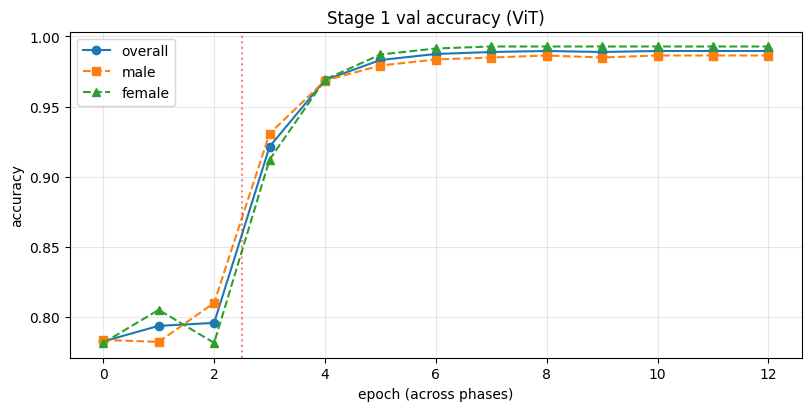

In [16]:
# Plot training curves
import matplotlib.pyplot as plt
if all_history:
    fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
    x = range(len(all_history))
    ax.plot(x, [h['accuracy'] for h in all_history], 'o-', label='overall')
    ax.plot(x, [h['male_acc'] for h in all_history], 's--', label='male')
    ax.plot(x, [h['female_acc'] for h in all_history], '^--', label='female')
    ax.set_xlabel('epoch (across phases)'); ax.set_ylabel('accuracy')
    ax.set_title('Stage 1 val accuracy (ViT)'); ax.legend(); ax.grid(True, alpha=0.3)
    phases = [h['phase'] for h in all_history]
    for i, ph in enumerate(phases):
        if i > 0 and ph != phases[i-1]:
            ax.axvline(i-0.5, color='red', linestyle=':', alpha=0.5)
    plt.show()


In [17]:
# Copy stage 1 checkpoint to Google Drive for persistence
import shutil
stage1_drive = os.path.join(DRIVE_CKPT_DIR, 'stage1')
if os.path.exists(stage1_drive): shutil.rmtree(stage1_drive)
shutil.copytree(os.path.join(s1['output_dir'], 'best'), stage1_drive)
print(f'Copied stage 1 best checkpoint to {stage1_drive}')
print('You can safely close Colab and resume stage 2 later from this Drive copy.')


Copied stage 1 best checkpoint to /content/drive/MyDrive/IPD_checkpoints/stage1
You can safely close Colab and resume stage 2 later from this Drive copy.


In [18]:
import shutil
from google.colab import files
shutil.make_archive("/content/stage1_best", "zip",
                        "/content/checkpoints/stage1/best")
print("Zipped. Size:")
!ls -lh /content/stage1_best.zip

Zipped. Size:
-rw-r--r-- 1 root root 306M Jul  4 16:57 /content/stage1_best.zip


In [19]:
files.download("/content/stage1_best.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
# === Test Stage 1 model on a video ===
# Pipeline: YOLO detects people per frame -> crop each person -> classify gender -> annotate -> write output video

from ultralytics import YOLO
import cv2

# --- 1. Upload video ---
print('Upload a video file (.mp4, .mov, etc.)')
up = files.upload()
video_path = list(up.keys())[0]
print(f'Using video: {video_path}')

# --- 2. Load models ---
detector = YOLO('yolov8n.pt')  # auto-downloads, class 0 = 'person' in COCO

ckpt = os.path.join(s1['output_dir'], 'best')
print(f'Loading gender classifier from: {ckpt}')
gender_model = GenderClassifier.load(ckpt, device=DEVICE)

# --- 3. Config ---
CONF_THRESH = 0.4       # YOLO person-detection confidence threshold
FRAME_SKIP = 1          # process every Nth frame (raise this to speed things up)
OUTPUT_PATH = '/content/output_annotated.mp4'

# --- 4. Open video ---
cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS) or 25
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f'Video: {w}x{h} @ {fps:.1f}fps, {n_frames} frames')

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer = cv2.VideoWriter(OUTPUT_PATH, fourcc, fps, (w, h))

COLORS = {'male': (255, 140, 0), 'female': (255, 20, 147)}  # BGR

frame_idx = 0
t0 = time.time()
while True:
    ret, frame = cap.read()
    if not ret:
        break

    if frame_idx % FRAME_SKIP == 0:
        # --- Detect people ---
        results = detector(frame, classes=[0], conf=CONF_THRESH, verbose=False)[0]

        for box in results.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(w, x2), min(h, y2)
            if x2 <= x1 or y2 <= y1:
                continue

            crop_bgr = frame[y1:y2, x1:x2]
            crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
            pil_crop = Image.fromarray(crop_rgb)

            pixel_values = val_transform(pil_crop).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                logits = gender_model(pixel_values)
                probs = torch.softmax(logits, dim=-1)[0]
            pred = int(probs.argmax())
            label = gender_model.id2label[pred]
            conf = probs[pred].item()

            color = COLORS[label]
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
            text = f'{label} {conf:.2f}'
            (tw, th), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            cv2.rectangle(frame, (x1, y1 - th - 8), (x1 + tw + 4, y1), color, -1)
            cv2.putText(frame, text, (x1 + 2, y1 - 4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

    writer.write(frame)
    frame_idx += 1
    if frame_idx % 50 == 0:
        elapsed = time.time() - t0
        eta = elapsed / frame_idx * (n_frames - frame_idx)
        print(f'  frame {frame_idx}/{n_frames}  elapsed={elapsed:.0f}s  eta={eta:.0f}s')

cap.release()
writer.release()
print(f'\nDone. Annotated video saved to: {OUTPUT_PATH}')

# --- 5. Download result ---
files.download(OUTPUT_PATH)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Upload a video file (.mp4, .mov, etc.)


Saving 1_47min.mp4 to 1_47min.mp4
Using video: 1_47min.mp4
Loading gender classifier from: /content/checkpoints/stage1/best


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Video: 848x478 @ 12.3fps, 1309 frames
  frame 50/1309  elapsed=2s  eta=52s
  frame 100/1309  elapsed=4s  eta=45s
  frame 150/1309  elapsed=6s  eta=47s
  frame 200/1309  elapsed=9s  eta=48s
  frame 250/1309  elapsed=13s  eta=55s
  frame 300/1309  elapsed=16s  eta=52s
  frame 350/1309  elapsed=18s  eta=50s
  frame 400/1309  elapsed=21s  eta=47s
  frame 450/1309  elapsed=24s  eta=45s
  frame 500/1309  elapsed=27s  eta=44s
  frame 550/1309  elapsed=29s  eta=41s
  frame 600/1309  elapsed=32s  eta=37s
  frame 650/1309  elapsed=34s  eta=35s
  frame 700/1309  elapsed=37s  eta=32s
  frame 750/1309  elapsed=39s  eta=29s
  frame 800/1309  elapsed=42s  eta=26s
  frame 850/1309  elapsed=43s  eta=23s
  frame 900/1309  elapsed=45s  eta=20s
  frame 950/1309  elapsed=47s  eta=18s
  frame 1000/1309  elapsed=48s  eta=15s
  frame 1050/1309  elapsed=50s  eta=12s
  frame 1100/1309  elapsed=52s  eta=10s
  frame 1150/1309  elapsed=55s  eta=8s
  frame 1200/1309  elapsed=56s  eta=5s
  frame 1250/1309  elapsed=5

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 5. Stage 2 — Fine-tune on YOUR data, lower LR

Place your labeled images in folder-per-class layout:
```
data/user/
  male/*.jpg
  female/*.jpg
```

Upload via Colab upload widget.

Two phases:
- **Phase A** (2 epochs, linear probe @ 1e-4): head only
- **Phase B** (5 epochs, full fine-tune @ 1e-6): everything

LR is 1/10 of stage 1 (your spec).

In [ ]:
# Upload your labeled data (folder-per-class) as a zip
# Zip structure: user.zip should contain user/male/*.jpg and user/female/*.jpg
print('Upload user.zip containing male/ and female/ subfolders')
try:
    up = files.upload()
    fname = list(up.keys())[0]
    import zipfile
    with zipfile.ZipFile(fname) as zf:
        zf.extractall('/content/data/')
    print(f'Extracted {fname} to /content/data/')
except Exception as e:
    print('Upload failed:', e)
    print('Alternative: manually place images in /content/data/user/{male,female}/')

user_root = Path(CONFIG['stage2']['user_data_root'])
if user_root.exists():
    for cls in ('male', 'female'):
        d = user_root / cls
        if d.exists():
            n = len(list(d.glob('*.jpg'))) + len(list(d.glob('*.JPG')))
            print(f'  {cls}: {n} images')
        else:
            print(f'  {cls}: MISSING folder')
else:
    print(f'  {user_root} does not exist yet')


In [ ]:
# Build stage 2 dataloaders
s2 = CONFIG['stage2']

init_from = s2['init_from']
if not Path(init_from).exists():
    drive_alt = os.path.join(DRIVE_CKPT_DIR, 'stage1')
    if Path(drive_alt).exists():
        print(f'Local {init_from} missing, using Drive copy: {drive_alt}')
        init_from = drive_alt
    else:
        raise FileNotFoundError(f'Stage 1 checkpoint not found at {init_from} or {drive_alt}')

full_val = FolderPerClassDataset(s2['user_data_root'], transform=val_transform)
full_train = FolderPerClassDataset(s2['user_data_root'], transform=train_transform)
tr_idx, va_idx = stratified_split(full_val.rows, s2['val_ratio'], CONFIG['seed'])
print(f'Stage 2: train={len(tr_idx)} val={len(va_idx)}')
if len(tr_idx) < 50:
    print('WARNING: very small dataset. Consider lowering LR further.')

s2_train_loader = DataLoader(Subset(full_train, tr_idx),
                             batch_size=s2['batch_size'], shuffle=True,
                             num_workers=s2['num_workers'],
                             pin_memory=True, drop_last=True)
s2_val_loader = DataLoader(Subset(full_val, va_idx),
                           batch_size=s2['eval_batch_size'], shuffle=False,
                           num_workers=s2['num_workers'], pin_memory=True)
print('Stage 2 dataloaders ready.')


In [ ]:
# Load stage 1 checkpoint + run Stage 2
print(f'Loading stage 1 checkpoint from {init_from}')
model = GenderClassifier.load(init_from, device=DEVICE)
os.makedirs(s2['output_dir'], exist_ok=True)

best_acc_s2 = 0.0
history_s2 = []

# Phase A: linear probe at 1/10 stage 1 LR
best_acc_s2, h = train_phase(
    model, s2_train_loader, s2_val_loader, DEVICE,
    phase_name='S2-A', epochs=s2['phase_a_epochs'],
    head_lr=s2['phase_a_head_lr'], backbone_lr=0.0, freeze=True,
    weight_decay=s2['weight_decay'], warmup_ratio=s2['warmup_ratio'],
    grad_clip=s2['grad_clip'], fp16=s2['fp16'], log_every=s2['log_every'],
    output_dir=s2['output_dir'], best_acc=best_acc_s2)
history_s2.extend(h)

# Phase B: full fine-tune at 1/10 stage 1 LR
best_acc_s2, h = train_phase(
    model, s2_train_loader, s2_val_loader, DEVICE,
    phase_name='S2-B', epochs=s2['phase_b_epochs'],
    head_lr=s2['phase_b_head_lr'], backbone_lr=s2['phase_b_backbone_lr'],
    freeze=False,
    weight_decay=s2['weight_decay'], warmup_ratio=s2['warmup_ratio'],
    grad_clip=s2['grad_clip'], fp16=s2['fp16'], log_every=s2['log_every'],
    output_dir=s2['output_dir'], best_acc=best_acc_s2)
history_s2.extend(h)

model.save(os.path.join(s2['output_dir'], 'final'))
with open(os.path.join(s2['output_dir'], 'history.json'), 'w') as f:
    json.dump(history_s2, f, indent=2)

print(f'\n=== STAGE 2 COMPLETE ===')
print(f'Best val accuracy: {best_acc_s2:.4f}')
print(f'Best checkpoint:   {s2["output_dir"]}/best')
print(f'Final checkpoint:  {s2["output_dir"]}/final')


In [ ]:
# Plot stage 2 curves
if history_s2:
    fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
    x = range(len(history_s2))
    ax.plot(x, [h['accuracy'] for h in history_s2], 'o-', label='overall')
    ax.plot(x, [h['male_acc'] for h in history_s2], 's--', label='male')
    ax.plot(x, [h['female_acc'] for h in history_s2], '^--', label='female')
    ax.set_xlabel('epoch'); ax.set_ylabel('accuracy')
    ax.set_title('Stage 2 val accuracy (ViT)'); ax.legend(); ax.grid(True, alpha=0.3)
    plt.show()


In [ ]:
# Copy stage 2 checkpoint to Google Drive
stage2_drive = os.path.join(DRIVE_CKPT_DIR, 'stage2')
if os.path.exists(stage2_drive): shutil.rmtree(stage2_drive)
shutil.copytree(os.path.join(s2['output_dir'], 'best'), stage2_drive)
print(f'Copied stage 2 best checkpoint to {stage2_drive}')


## 6. Quick eval on a test image

Upload any face/body image and see the model's prediction.

In [ ]:
from google.colab import files
from IPython.display import display

up = files.upload()
test_img_path = list(up.keys())[0]

ckpt = os.path.join(s2['output_dir'], 'best')
if not Path(ckpt).exists():
    ckpt = os.path.join(s1['output_dir'], 'best')
print(f'Using checkpoint: {ckpt}')
m = GenderClassifier.load(ckpt, device=DEVICE)

img = Image.open(test_img_path).convert('RGB')
display(img.resize((224, 224)))
pixel_values = val_transform(img).unsqueeze(0).to(DEVICE)
with torch.no_grad():
    logits = m(pixel_values)
    probs = torch.softmax(logits, dim=-1)[0]
pred = int(probs.argmax())
print(f'\nPrediction: {m.id2label[pred]}')
print(f'  female: {probs[0].item():.3f}')
print(f'  male:   {probs[1].item():.3f}')


## 7. Use the fine-tuned ViT in the inference pipeline

After stage 2, your checkpoint is at `checkpoints/stage2/best/`.  
The fine-tuned ViT replaces both the face ViT and CLIP body-gender in the inference notebook:

1. Open `gender_pipeline.ipynb`
2. In the CONFIG cell, set:
   ```python
   CONFIG['face_gender']['model'] = '/content/checkpoints/stage2/best'
   ```
3. The `FaceViTGender` class loads the checkpoint via `GenderClassifier.load()`
4. For body-based gender, the same ViT is used (no more CLIP zero-shot)
5. For ReID, the ViT's `embed()` method provides 768-dim features for cosine similarity

**Why this is better than fine-tuning CLIP:**
- CLIP's value is the joint image-text space; reducing it to a binary head wastes that
- ViT is pretrained on ImageNet-21k for pure visual classification — better suited for attribute tasks
- The fine-tuned ViT provides both classification AND ReID embeddings from a single model
- Smaller, simpler, no language component to drag along

## Done

Both checkpoints are saved to Google Drive at `IPD_checkpoints/{stage1,stage2}/`.  
You can close Colab; the checkpoints persist.
